# Project Overview
Given the dataset regression.csv, create a predictive model for the target variable y defined by: y = count / max(count) import pandas as pd ; df = pd.read_csv('regression.csv') ; df["y"] = df["count"] / df["count"].max()

- To get an understanding of the periodic patterns of the data, have a look at the count variable per hour during a week.
- Since the dataset is a time-ordered event log (hourly demand), use a time-sensitive cross-validation splitter to evaluate the model.

\begin{equation}
    y = \frac{\text{count}}{\max(\text{count})}
\end{equation}

# Import Libraries

In [36]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


# Get Data

In [11]:
df = pd.read_csv('regression.csv')

In [3]:
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


In [12]:
df["y"] = df["count"] / df["count"].max()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  object 
 1   year        17379 non-null  int64  
 2   month       17379 non-null  int64  
 3   hour        17379 non-null  int64  
 4   holiday     17379 non-null  bool   
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  bool   
 7   weather     17379 non-null  object 
 8   temp        17379 non-null  float64
 9   feel_temp   17379 non-null  float64
 10  humidity    17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  count       17379 non-null  int64  
 13  y           17379 non-null  float64
dtypes: bool(2), float64(5), int64(5), object(2)
memory usage: 1.6+ MB


In [123]:
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count,y
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16,0.016377
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40,0.040942
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32,0.032753
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13,0.013306
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1,0.001024


<Axes: >

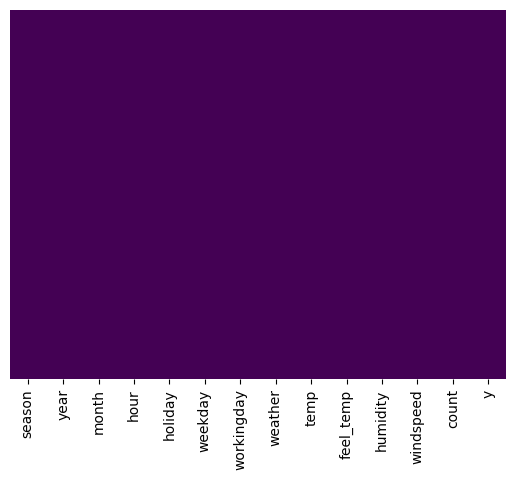

In [124]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

# EDA

<Axes: >

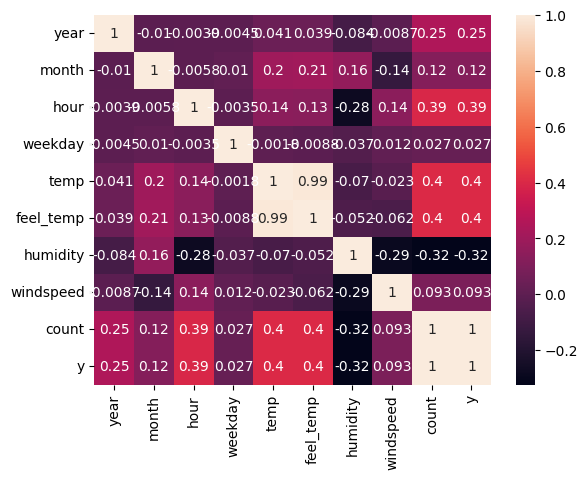

In [125]:
# Seleccionar solo las columnas numéricas
numerical_df = df.select_dtypes(include='number')
# Mostrar la matriz de correlación de las columnas numéricas de 'tips'
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix,annot=True)

In [126]:
df.pivot_table(values='y',index='month',columns='year')

year,0,1
month,,
1,0.056814,0.133632
2,0.076040,0.152551
3,0.089798,0.227128
4,0.135053,0.248364
5,0.186853,0.269457
6,0.204015,0.288340
7,0.194447,0.280108
8,0.191394,0.295098
9,0.181893,0.310720


# To get an understanding of the periodic patterns of the data, have a look at the count variable per hour during a week.

## Suma

In [128]:
df.groupby(by=['weekday','hour']).sum()['count'].unstack()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,9775,8053,6286,3239,955,852,1493,3476,8805,16437,...,38181,37163,37317,33471,28626,23675,17643,13403,9883,6499
1,3571,1800,1021,496,567,2252,8930,25848,42868,22718,...,20041,21046,29583,52249,50060,35836,25176,18152,12039,6802
2,2790,1254,687,382,508,2470,10863,30569,48122,24118,...,17510,19438,29817,56605,53827,36808,26332,19368,13757,7922
3,3594,1595,797,484,477,2678,11212,31614,50786,24807,...,17737,18854,28388,53367,50885,36823,26436,20051,14800,8625
4,4045,1774,934,497,528,2669,11066,31388,50323,24810,...,18289,20237,29775,54844,52218,37279,27967,20580,15313,10062
5,5453,2571,1325,673,589,2486,9363,26450,48077,26935,...,23854,26256,34423,51211,43783,31415,22186,17667,15295,11982
6,9902,7117,5302,2403,804,854,2205,4826,12020,19613,...,40040,40155,38445,35113,30373,24953,18810,16224,14525,12049


In [129]:
pivot_sum = df.pivot_table(values='count',index='weekday',columns='hour',aggfunc='sum')
pivot_sum

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,9775,8053,6286,3239,955,852,1493,3476,8805,16437,...,38181,37163,37317,33471,28626,23675,17643,13403,9883,6499
1,3571,1800,1021,496,567,2252,8930,25848,42868,22718,...,20041,21046,29583,52249,50060,35836,25176,18152,12039,6802
2,2790,1254,687,382,508,2470,10863,30569,48122,24118,...,17510,19438,29817,56605,53827,36808,26332,19368,13757,7922
3,3594,1595,797,484,477,2678,11212,31614,50786,24807,...,17737,18854,28388,53367,50885,36823,26436,20051,14800,8625
4,4045,1774,934,497,528,2669,11066,31388,50323,24810,...,18289,20237,29775,54844,52218,37279,27967,20580,15313,10062
5,5453,2571,1325,673,589,2486,9363,26450,48077,26935,...,23854,26256,34423,51211,43783,31415,22186,17667,15295,11982
6,9902,7117,5302,2403,804,854,2205,4826,12020,19613,...,40040,40155,38445,35113,30373,24953,18810,16224,14525,12049


## Mean

In [130]:
pivot = df.pivot_table(index='weekday', columns='hour', values='count', aggfunc='mean')
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,93.990385,77.432692,61.627451,31.144231,9.362745,8.693878,14.495146,33.104762,83.857143,156.542857,...,363.628571,353.933333,355.400000,318.771429,272.628571,225.476190,168.028571,127.647619,94.123810,61.895238
1,34.009524,17.307692,10.313131,5.113402,5.785714,21.653846,85.865385,248.538462,412.192308,218.442308,...,192.701923,202.365385,284.451923,502.394231,481.346154,344.576923,242.076923,174.538462,115.759615,65.403846
2,27.623762,12.540000,6.801980,4.152174,5.131313,24.455446,106.500000,299.696078,471.784314,236.450980,...,168.365385,186.903846,286.701923,544.278846,517.567308,353.923077,253.192308,186.230769,132.278846,76.173077
3,34.557692,15.336538,7.813725,4.888889,4.968750,25.750000,107.807692,303.980769,488.326923,238.528846,...,170.548077,181.288462,272.961538,513.144231,494.029126,357.504854,256.660194,194.669903,143.689320,83.737864
4,39.271845,17.223301,9.156863,5.071429,5.280000,25.912621,107.436893,304.737864,488.572816,240.873786,...,177.563107,196.475728,286.298077,527.346154,502.096154,358.451923,268.913462,197.884615,147.240385,96.750000
5,52.432692,24.721154,12.740385,6.598039,6.072165,23.903846,90.028846,254.326923,462.278846,258.990385,...,229.365385,252.461538,330.990385,492.413462,420.990385,302.067308,213.326923,169.875000,147.067308,115.211538
6,94.304762,67.780952,50.495238,22.885714,7.657143,8.291262,21.000000,45.961905,114.476190,186.790476,...,381.333333,382.428571,366.142857,334.409524,292.048077,239.932692,180.865385,156.000000,139.663462,115.855769


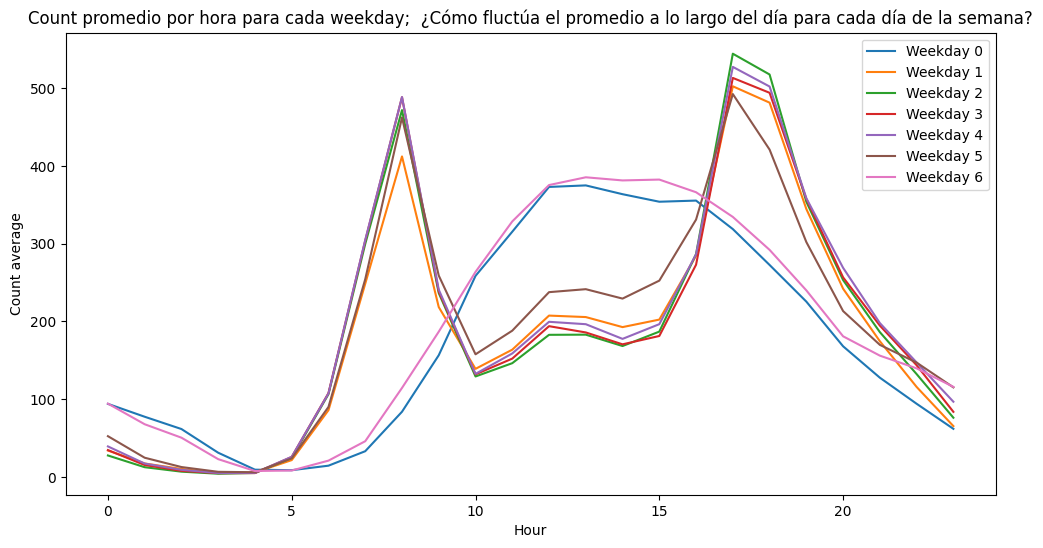

In [131]:
plt.figure(figsize=(12,6))
for weekday in pivot.index:
    plt.plot(pivot.columns, pivot.loc[weekday], label=f'Weekday {weekday}')

plt.legend()
plt.xlabel('Hour')
plt.ylabel('Count average')
plt.title('Count promedio por hora para cada weekday;  ¿Cómo fluctúa el promedio a lo largo del día para cada día de la semana?')
plt.show()

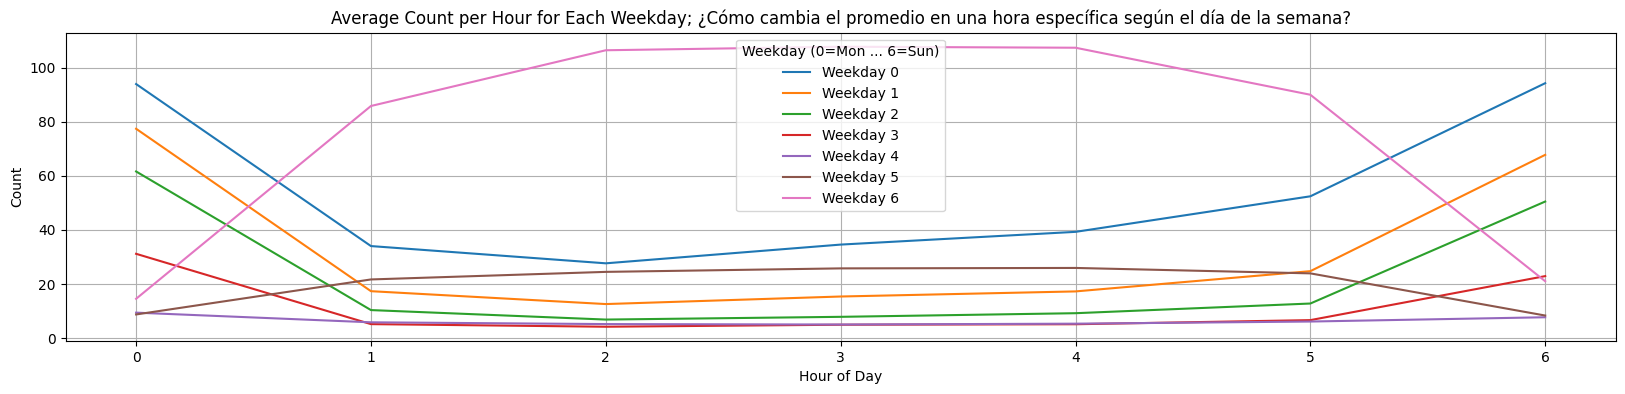

In [114]:
plt.figure(figsize=(20,4))
for wd in range(7):
    plt.plot(pivot.index, pivot[wd], label=f'Weekday {wd}')

plt.title('Average Count per Hour for Each Weekday; ¿Cómo cambia el promedio en una hora específica según el día de la semana?')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.legend(title='Weekday (0=Mon ... 6=Sun)')
plt.grid(True)
plt.show()

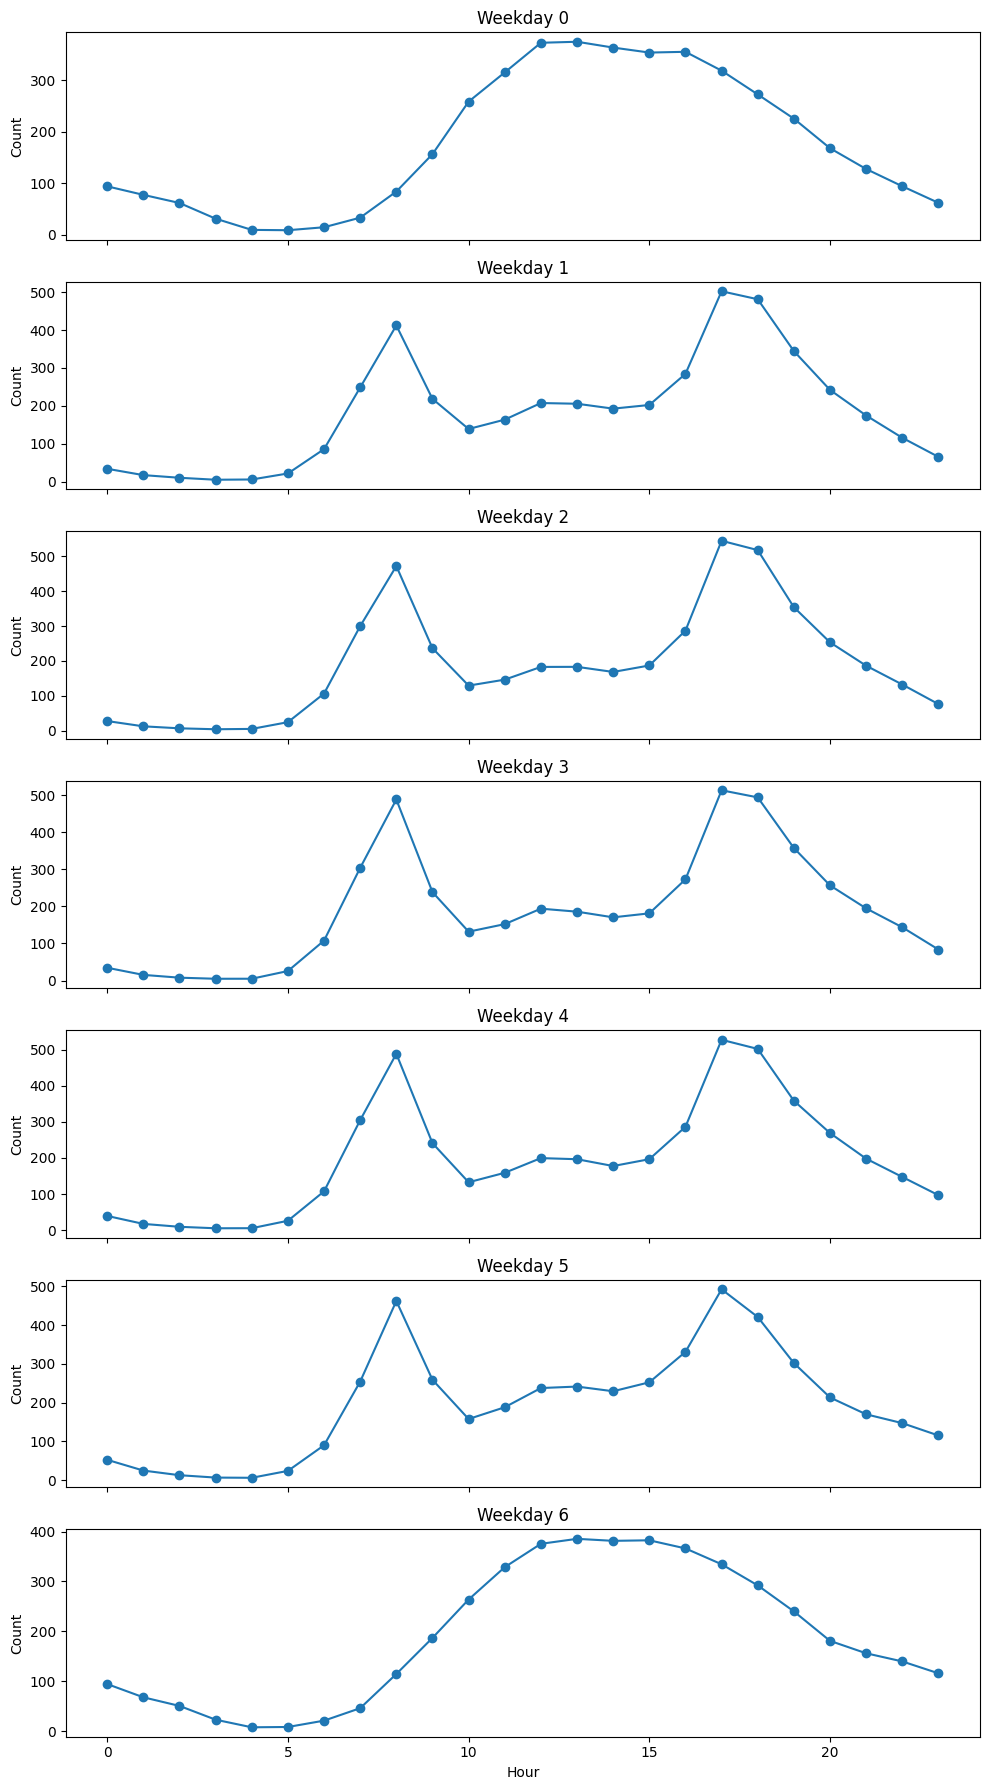

In [117]:
weekday_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6"
}

fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10,18), sharex=True)

for i, weekday in enumerate(pivot.index):
    axes[i].plot(pivot.columns, pivot.loc[weekday], marker="o")
    axes[i].set_title(f"Weekday {weekday_map.get(weekday, weekday)}")
    axes[i].set_ylabel("Count")
    
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

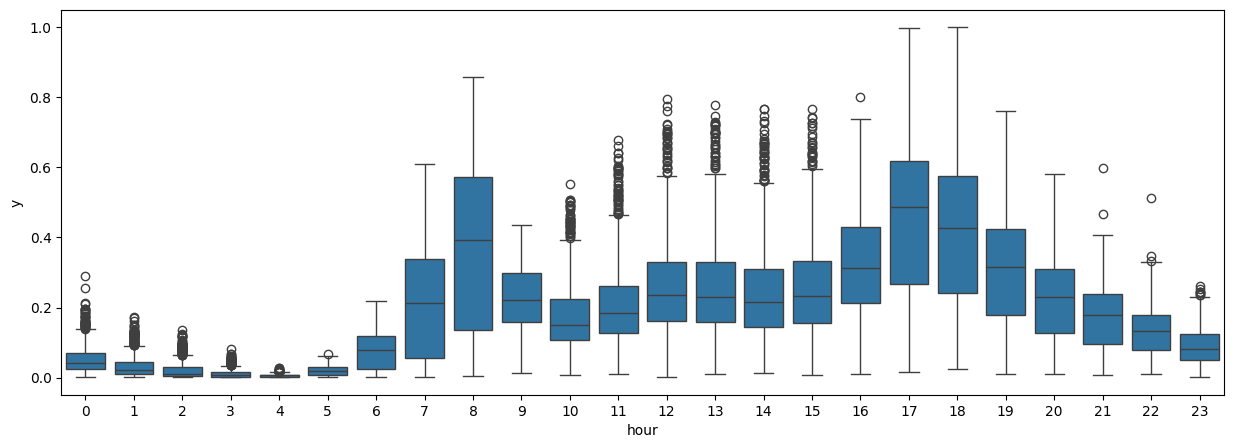

In [19]:
plt.figure(figsize=(15, 5))
sns.boxplot(x='hour', y='y', data=df)
plt.show()

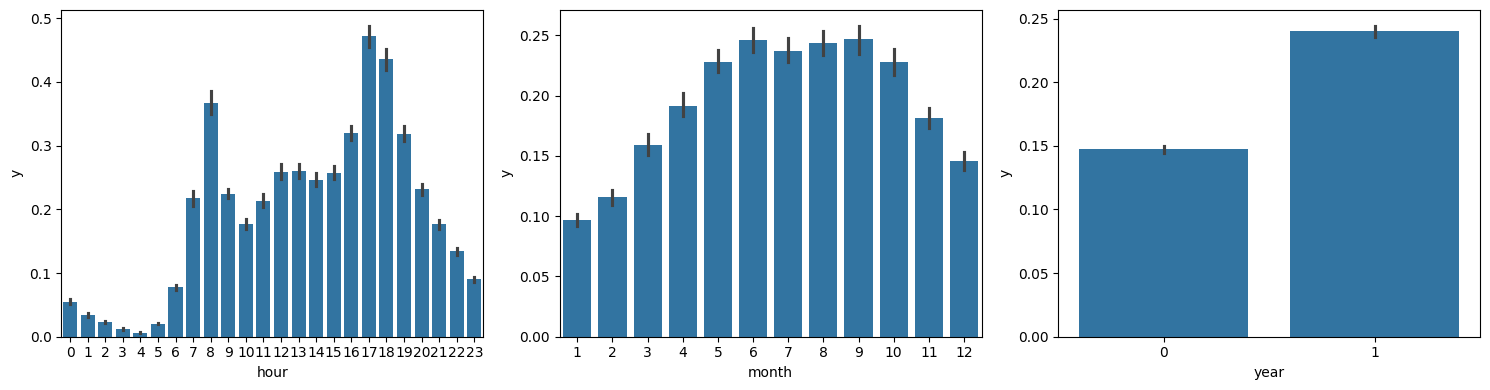

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x='hour', y='y', ax=axs[0])
sns.barplot(data=df, x='month', y='y', ax=axs[1])
sns.barplot(data=df, x='year', y='y', ax=axs[2])

plt.tight_layout()
plt.show()

Se observa que hay horas y meses pico, por lo cual se generan dos nuevos features al dataset. 

In [21]:
df['peak_hour'] = df['hour'].apply(lambda x: x in [8, 16, 17, 18, 19]).astype(int)
df['peak_month'] = df['month'].apply(lambda x: x in [6, 7, 8, 9, 10]).astype(int)

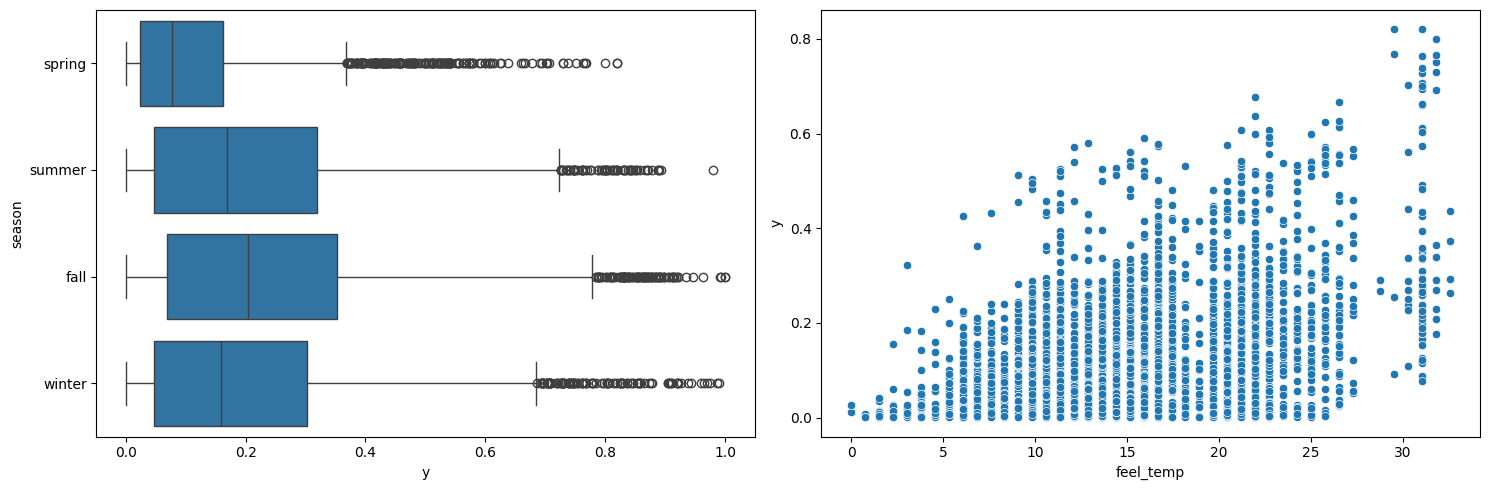

In [22]:
df_spring = df[df['season'] == 'spring']

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='y', y='season', ax=axs[0])
sns.scatterplot(data=df_spring, x='feel_temp', y='y', ax=axs[1])

plt.tight_layout()
plt.show()

*Se observan outliers en todos los casos. El comportamiento de los datos es similar entre los distintos elementos, salvo para el caso de spring. Al graficar esos datos en función de feel_temp se observa que los outliers corresponden a temperaturas altas.*


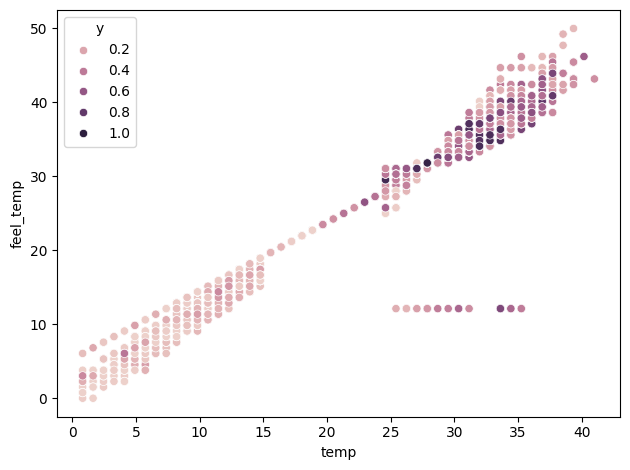

In [23]:
sns.scatterplot(data=df, x='temp', y='feel_temp', hue='y')
plt.tight_layout()
plt.show()

*Los datos de temp y feel_temp presentan una alta correlación, lo cual puede producir sesgos en el modelo. Además, se espera que feel_temp sea consecuencia de la combinación de otros datos meteorológicos con los que se cuenta en el dataset.*

In [24]:
df = df.drop('feel_temp', axis=1)

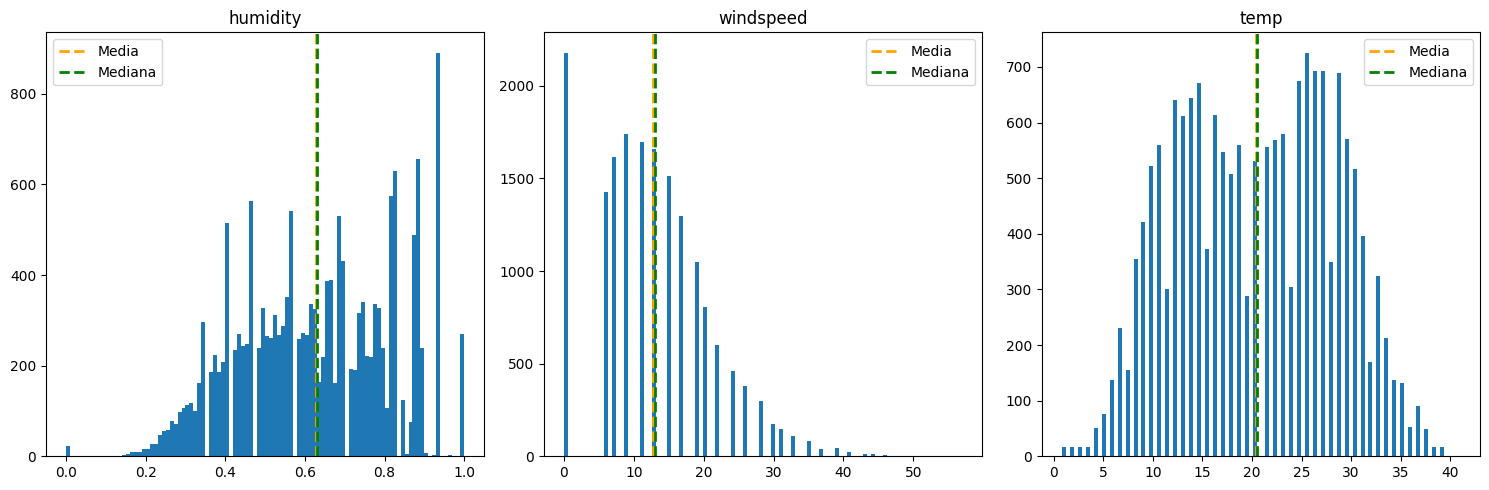

In [27]:
weather_features = ['temp', 'humidity', 'windspeed']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(weather_features):
    ax = axes[i-1]
    
    feature_data = df[feature]
    ax.hist(feature_data, bins=100)
    
    ax.axvline(feature_data.mean(), color='orange', linestyle='dashed', linewidth=2, label='Media')
    ax.axvline(feature_data.median(), color='green', linestyle='dashed', linewidth=2, label='Mediana')
    
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

*Se observan outlier en cero para windspeed y para humidity. Se sosprecha que esto corresponde a missing values a partir de la forma que posee la distribución. Se buscará realizar un tratamiento de dichos valores posteriormente.*

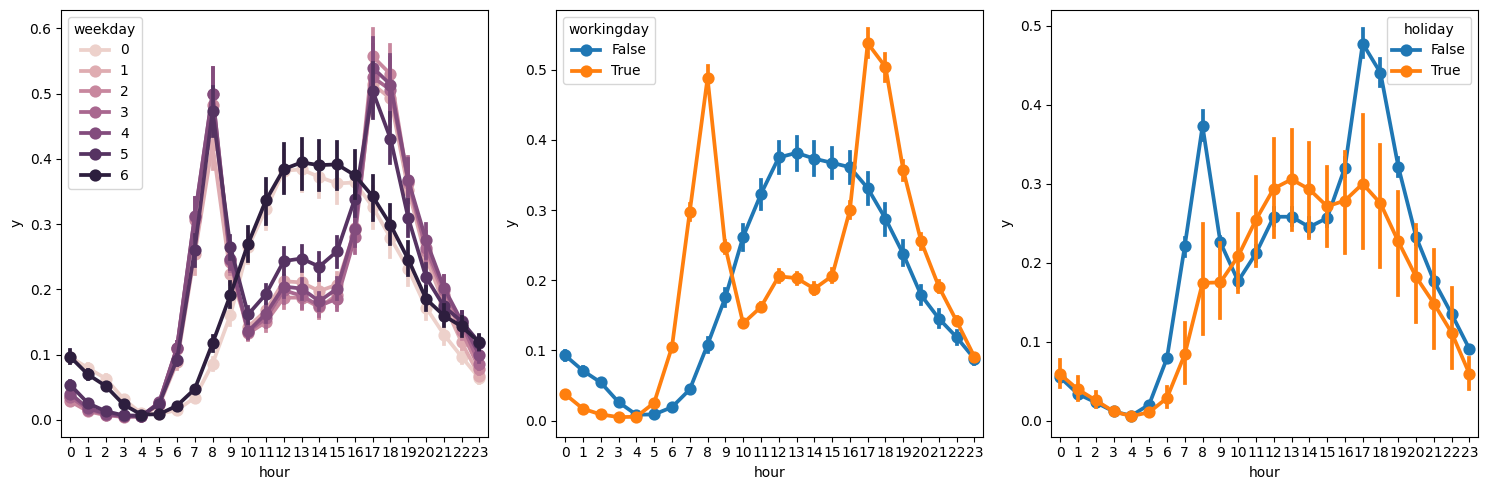

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.pointplot(data=df, x='hour', y='y', hue='weekday', ax=axs[0])
sns.pointplot(data=df, x='hour', y='y', hue='workingday', ax=axs[1])
sns.pointplot(data=df, x='hour', y='y', hue='holiday', ax=axs[2])

plt.tight_layout()
plt.show()


*Se puede observar un comportamiento inverso entre las figuras 2 y 3. Esto se debe a estar en dos situaciones complemetarias entre sí. Se muestran horarios pico durante para holiday = 1 pasado el mediodía. Mientras que para workingday = 1 se observan picos en los horarios de ingreso y egreso laboral. A su vez, la figura 1 representa comportamientos similares, donde los holiday = 1 se corresponderían a los días de la semana 0 y 6, mientras que los workingday = 1 se corresponderían a los días 1 a 5* 

*Se podría intentar ver si algúno de estos features puede ser recuperado en la combinación de los otros dos.*

# Categorical Features

## Season

<Axes: xlabel='season', ylabel='count'>

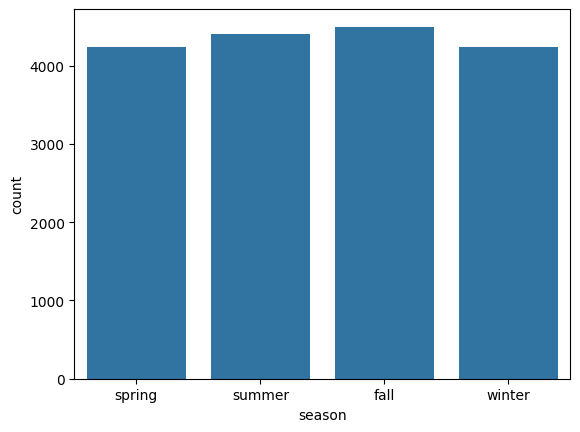

In [6]:
sns.countplot(x='season',data=df)

In [7]:
# Calcular los valores absolutos
season_cant = df['season'].value_counts()
# Calcular los porcentajes
season_perc = 100 * season_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': season_cant, 'Porcentaje': season_perc})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

        Cantidad  Porcentaje
season                      
fall        4496       25.87
summer      4409       25.37
spring      4242       24.41
winter      4232       24.35


## Weather

<Axes: xlabel='weather', ylabel='count'>

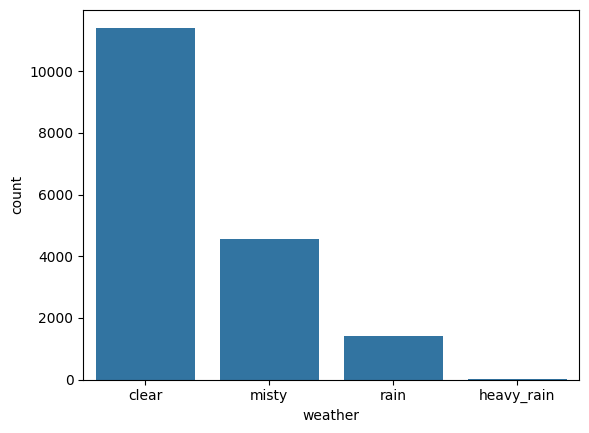

In [53]:
sns.countplot(x='weather',data=df)

In [133]:
# Calcular los valores absolutos
weather_cant = df['weather'].value_counts()
# Calcular los porcentajes
weather_perc = 100 * weather_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': weather_cant, 'Porcentaje': weather_perc})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

            Cantidad  Porcentaje
weather                         
clear          11413       65.67
misty           4544       26.15
rain            1419        8.17
heavy_rain         3        0.02


## Data Transformation

In [25]:
cat_feats = ['season','weather']
cat_feats

['season', 'weather']

In [26]:
# A df le agregamos al final columnas que son los valores que vienen en las columnas categóricas del original, y les ponemos 0 o 1
final_data = pd.get_dummies(df,columns=cat_feats,drop_first=True)
     #drop_first=True: De cada variable categórica elimina la primera categoría (evita variables dummies redundantes).
final_data.head()

,year,month,hour,holiday,weekday,workingday,temp,humidity,windspeed,count,y,peak_hour,peak_month,season_spring,season_summer,season_winter,weather_heavy_rain,weather_misty,weather_rain
0,0,1,0,False,6,False,9.84,0.81,0.0,16,0.016377,0,0,True,False,False,False,False,False
1,0,1,1,False,6,False,9.02,0.80,0.0,40,0.040942,0,0,True,False,False,False,False,False
2,0,1,2,False,6,False,9.02,0.80,0.0,32,0.032753,0,0,True,False,False,False,False,False
3,0,1,3,False,6,False,9.84,0.75,0.0,13,0.013306,0,0,True,False,False,False,False,False
4,0,1,4,False,6,False,9.84,0.75,0.0,1,0.001024,0,0,True,False,False,False,False,False


In [16]:
final_data.replace({False: 0, True: 1}, inplace=True)

/tmp/ipykernel_194695/288088242.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_data.replace({False: 0, True: 1}, inplace=True)


In [17]:
final_data.head()

,year,month,hour,holiday,weekday,workingday,temp,feel_temp,humidity,windspeed,count,y,season_spring,season_summer,season_winter,weather_heavy_rain,weather_misty,weather_rain
0,0,1,0,0,6,0,9.84,14.395,0.81,0.0,16,0.016377,1,0,0,0,0,0
1,0,1,1,0,6,0,9.02,13.635,0.80,0.0,40,0.040942,1,0,0,0,0,0
2,0,1,2,0,6,0,9.02,13.635,0.80,0.0,32,0.032753,1,0,0,0,0,0
3,0,1,3,0,6,0,9.84,14.395,0.75,0.0,13,0.013306,1,0,0,0,0,0
4,0,1,4,0,6,0,9.84,14.395,0.75,0.0,1,0.001024,1,0,0,0,0,0


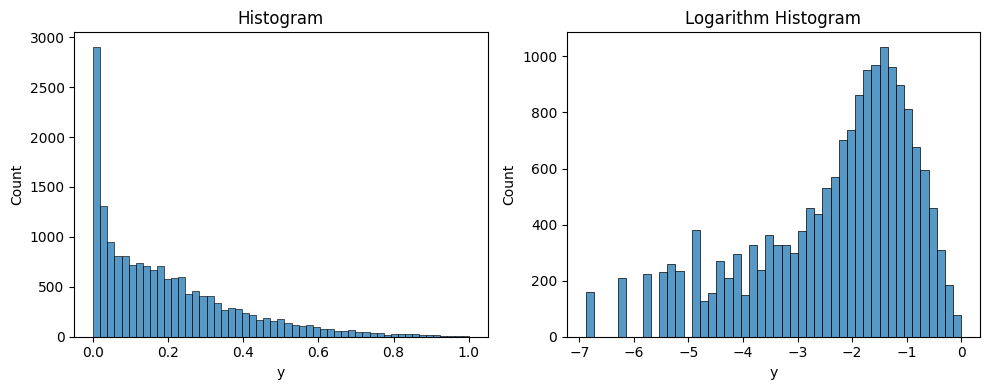

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(final_data['y'], ax=axs[0])
axs[0].set_title('Histogram')

sns.histplot(np.log(final_data['y']), ax=axs[1])
axs[1].set_title('Logarithm Histogram')

plt.tight_layout()
plt.show()

*El histograma de la distribución de y es asimétrica, por lo cual se grafíca también la distribución logarítmica. Se observa que la distribución logarítmica se asemeja a una distribución normal. Por esta razón a la hora de implementar un modelo se podría utilizar el logaritmo de los valores y.*

# Since the dataset is a time-ordered event log (hourly demand), use a time-sensitive cross-validation splitter to evaluate the model.

*Para realizar un modelo predictivo teniendo una serie temporal es necesario ordenar la información cronológicamente para que el set de test tenga data posterior al set de train. Aunque el dataset indica el número de día de la semana no es posible distinguir entre semanas dentro del mismo mes, por lo cual se usará el año y mes para ordenar la información.*

*Como la cantidad de datos a grande se utilizará holdout en lugar de usar k-fold validation. Para cada modelo se determina el error cuadrático MSE*

In [29]:
display(final_data['year'].value_counts())
display(final_data['month'].value_counts())

year
1    8734
0    8645
Name: count, dtype: int64

month
7     1488
5     1488
12    1483
8     1475
3     1473
10    1451
6     1440
4     1437
9     1437
11    1437
1     1429
2     1341
Name: count, dtype: int64

*Se tienen 24 meses, los cuales se ordenan para asiganar los primeros 19 meses a los datos de train y los siguientes 5 meses a los datos de validación. De este modo se obtiene un ~80% de datos para train y un ~20% de datos para validación.*

In [33]:
train = final_data[(final_data['year'] == 0) | ((final_data['year'] == 1) & (final_data['month'] <= 7))]
test = final_data[(final_data['year'] == 1) & (final_data['month'] > 7)]
X_columns = ['year', 
             'month', 
             'hour', 
             'holiday', 
             'weekday', 
             'workingday', 
             'temp',  
             'humidity', 
             'windspeed', 
             'weather_heavy_rain', 
             'weather_misty', 
             'weather_rain', 
             'season_spring', 
             'season_summer', 
             'season_winter',
             'peak_hour', 
             'peak_month']
y_columns = ['y']

X_train = train[X_columns]
y_train = train[y_columns]
X_test = test[X_columns]
y_test = test[y_columns]

# Training a Model

# 1) Linear Regression

In [37]:
linear_model = LinearRegression()
linear_model.fit(X_train, np.log(y_train))

y_pred_linear = linear_model.predict(X_test)
y_pred_linear = np.exp(y_pred_linear)

linear_msle = mean_squared_log_error(y_test, y_pred_linear)
print(f'MSLE (Linear Regression): {linear_msle}')

MSLE (Linear Regression): 0.018983140638553362


# 2) SVM

In [38]:
svr_model = SVR(kernel='linear')
svr_model.fit(X_train, np.log(y_train.values.ravel()))

y_pred_svm = svr_model.predict(X_test)
y_pred_svm = np.exp(y_pred_svm)

svm_msle = mean_squared_log_error(y_test, y_pred_svm)
print(f'MSLE (SVM Regression): {svm_msle}')

MSLE (SVM Regression): 0.016756531454581797


# 3) Random Forest

In [39]:
clf = RandomForestRegressor()

clf.fit(X_train, np.log(y_train.values.ravel()))

y_pred_rf = clf.predict(X_test)
y_pred_rf = np.exp(y_pred_rf)

rf_msle = mean_squared_log_error(y_test, y_pred_rf)
print(f'MSLE (Random Forest): {rf_msle}')

MSLE (Random Forest): 0.003219535327726571


# 4) Light GBM

In [40]:
model_lgb = LGBMRegressor()
model_lgb.fit(X_train, np.log(y_train))
y_pred_lgb = model_lgb.predict(X_test)

y_pred_lgb = np.exp(y_pred_lgb)
lgb_msle = mean_squared_log_error(y_test, y_pred_lgb)

print(f'MSLE (LightGBM): {lgb_msle}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 13747, number of used features: 16
[LightGBM] [Info] Start training from score -2.433959
MSLE (LightGBM): 0.0027731464030363545


# Comparison

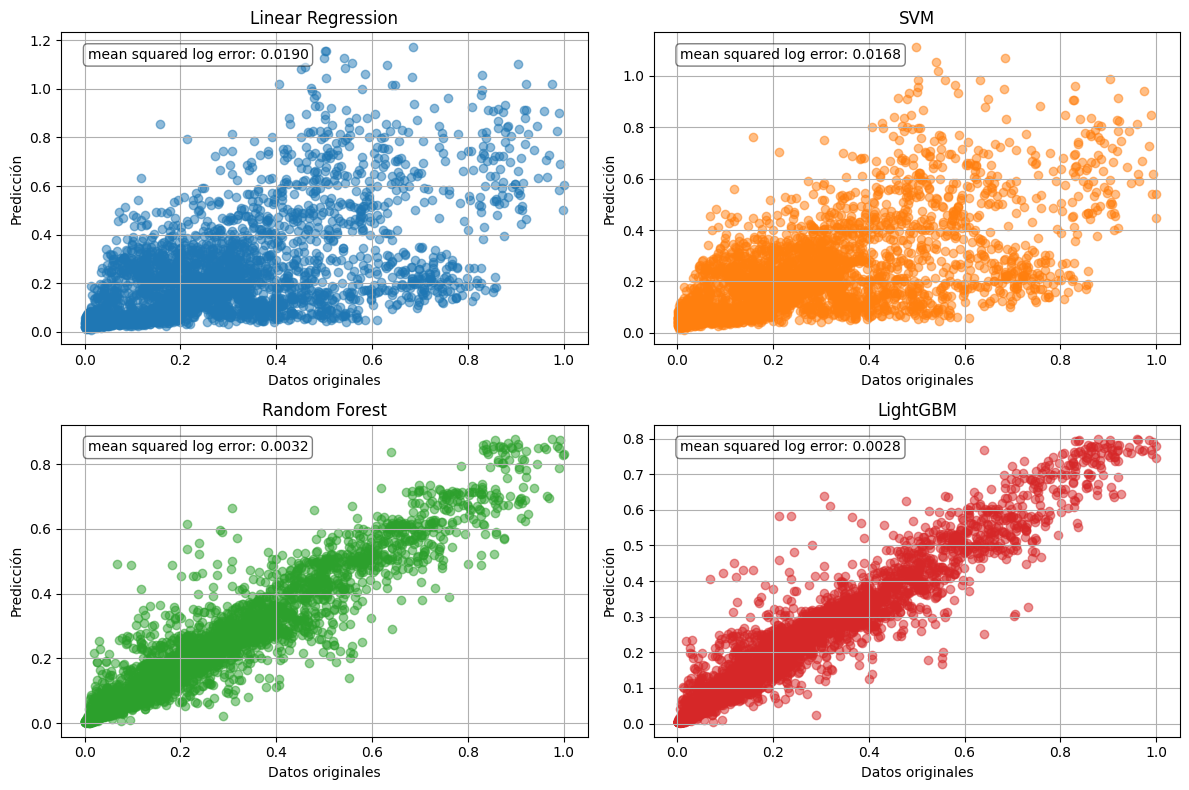

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

color = sns.color_palette()

models = ['Linear Regression', 'SVM', 'Random Forest', 'LightGBM']
predictions = [y_pred_linear, y_pred_svm, y_pred_rf, y_pred_lgb]
mses = [linear_msle, svm_msle, rf_msle, lgb_msle]

for i, ax in enumerate(axes.flat):
    ax.scatter(y_test, predictions[i], alpha=0.5, color=color[i])
    ax.set_title(models[i])
    ax.set_xlabel('Datos originales')
    ax.set_ylabel('Predicción')
    ax.grid(True)
    ax.text(0.05, 0.95, f'mean squared log error: {mses[i]:.4f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

*Los modelos de Random Forest y LightGBM presentan una buena correlación entre la predicción y los datos originales, siendo LightGBM el mejor modelo.* 

*Se probó utilizando un conjunto de validación para el caso de LightGBM pero los resultados optenidos no mejoraron la performance.*

*Se busca mejorar el modelo a partir de los hiperparámetros*

## Mejora de hiperparámetros

In [42]:
gridParams = {
    'learning_rate': [0.025, 0.05, 0.1],
    'num_leaves': [10, 20, 30, 50, 80, 120, 160, 200],
    'boosting_type' : ['gbdt'],
    'objective' : ['regression'],
    'max_depth' : [5, 6, 7, 8],
    'random_state' : [501], 
    'colsample_bytree' : [0.5, 0.7],
    'subsample' : [0.5, 0.7],
    'min_data_in_leaf':[10, 20, 30],
    'metric':['l2'],
    'feature_fraction': [0.7, 0.8, 0.9]
    }

In [43]:
iterations = 1_000
best_score = 5
best_params = {}
for i in range(iterations):
    params = {key : np.random.choice(values) for key, values in gridParams.items()}
    clf = lgb.LGBMRegressor(**params)
    clf.fit(X_train, np.log(y_train))
    y_pred_lgb = clf.predict(X_test)
    y_pred_lgb = np.exp(y_pred_lgb)
    lgb_msle = mean_squared_log_error(y_test, y_pred_lgb)

    if lgb_msle < best_score:
        best_score = lgb_msle
        best_params = params


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.7 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.7 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 13747, number of used features: 16
[LightGBM] [Info] Start training from score -2.433959
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

In [44]:
print(f'best_score: {best_score}, \nparameters: {best_params}')

best_score: 0.0024100278642365577, 
parameters: {'learning_rate': np.float64(0.1), 'num_leaves': np.int64(200), 'boosting_type': np.str_('gbdt'), 'objective': np.str_('regression'), 'max_depth': np.int64(8), 'random_state': np.int64(501), 'colsample_bytree': np.float64(0.5), 'subsample': np.float64(0.5), 'min_data_in_leaf': np.int64(30), 'metric': np.str_('l2'), 'feature_fraction': np.float64(0.8)}


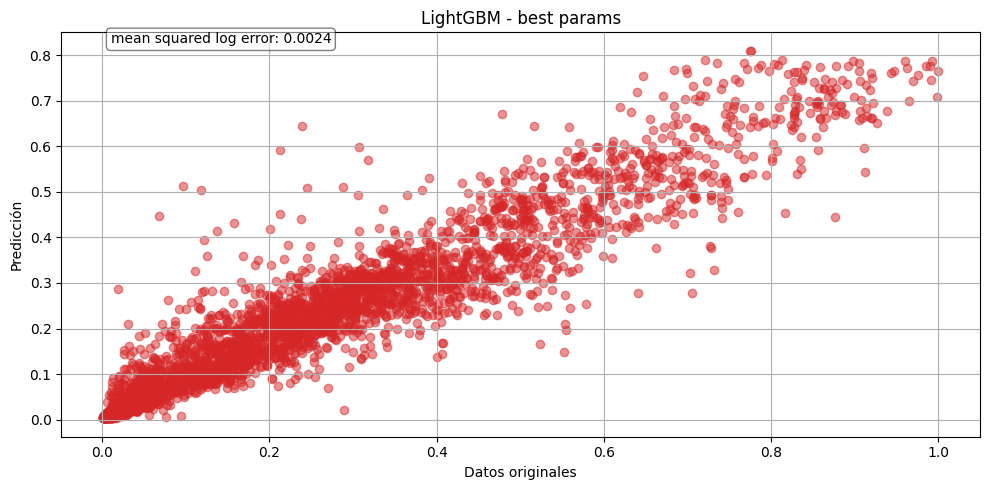

In [45]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred_lgb, alpha=0.5, color=color[3])
plt.title('LightGBM - best params')
plt.xlabel('Datos originales')
plt.ylabel('Predicción')

plt.grid(True)
plt.text(0.01, 0.85, f'mean squared log error: {best_score:.4f}', fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

*Por último, dado que en el análisis previo se observaron outliers en windspeed y humidity, se probó reemplazando esos valores usando mean, median y kNN. En ninguno de los casos se obtuvo un mejor rendimiento del modelo, por lo que se descartaron las opciones. Al final del notebook se encuentra los códigos comentados.*

### Windspeed (mean)

In [ ]:
# df_outlier_windspeed = df.copy()
# df_outlier_windspeed['windspeed'] = df_outlier_windspeed['windspeed'].replace(0, df_outlier_windspeed['windspeed'].mean())
# df_outlier_windspeed = df_outlier_windspeed.sort_values(by=['year', 'month'])

# train = df_outlier_windspeed[(df_outlier_windspeed['year'] == 0) | ((df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] <= 7))]
# test = df_outlier_windspeed[(df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] > 7)]

# X_train = train[X_columns]
# y_train = train[y_columns]
# X_test = test[X_columns]
# y_test = test[y_columns]

# model_lgb.fit(X_train, np.log(y_train))
# y_pred_lgb_a = model_lgb.predict(X_test)
# y_pred_lgb_a = np.exp(y_pred_lgb_a)

# print(f'MSLE (LightGBM) - Outlier (Windspeed = mean): {mean_squared_log_error(y_test, y_pred_lgb_a)}')

### Windspeed (median)

In [ ]:
# df_outlier_windspeed = df.copy()
# df_outlier_windspeed['windspeed'] = df_outlier_windspeed['windspeed'].replace(0, df_outlier_windspeed['windspeed'].median())
# df_outlier_windspeed = df_outlier_windspeed.sort_values(by=['year', 'month'])

# train = df_outlier_windspeed[(df_outlier_windspeed['year'] == 0) | ((df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] <= 7))]
# test = df_outlier_windspeed[(df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] > 7)]

# X_train = train[X_columns]
# y_train = train[y_columns]
# X_test = test[X_columns]
# y_test = test[y_columns]

# model_lgb.fit(X_train, np.log(y_train))
# y_pred_lgb_b = model_lgb.predict(X_test)
# y_pred_lgb_b = np.exp(y_pred_lgb_b)

# print(f'MSLE (LightGBM) - Outlier (Windspeed = median): {mean_squared_log_error(y_test, y_pred_lgb_b)}')

### Humidity (mean)

In [ ]:
# df_outlier_humidity = df.copy()
# df_outlier_humidity['humidity'] = df_outlier_humidity['humidity'].replace(0, df_outlier_humidity['humidity'].mean())
# df_outlier_humidity = df_outlier_humidity.sort_values(by=['year', 'month'])

# train = df_outlier_humidity[(df_outlier_humidity['year'] == 0) | ((df_outlier_humidity['year'] == 1) & (df_outlier_humidity['month'] <= 7))]
# test = df_outlier_humidity[(df_outlier_humidity['year'] == 1) & (df_outlier_humidity['month'] > 7)]

# X_train = train[X_columns]
# y_train = train[y_columns]
# X_test = test[X_columns]
# # y_test = test[y_columns]

# model_lgb.fit(X_train, np.log(y_train))
# y_pred_lgb_c = model_lgb.predict(X_test)
# y_pred_lgb_c = np.exp(y_pred_lgb_c)

# print(f'MSLE (LightGBM) - Outlier (humidity = mean): {mean_squared_log_error(y_test, y_pred_lgb_c)}')

### Humidity (median)

In [ ]:
# df_outlier_humidity = df.copy()
# df_outlier_humidity['humidity'] = df_outlier_humidity['humidity'].replace(0, df_outlier_humidity['humidity'].median())
# df_outlier_humidity = df_outlier_humidity.sort_values(by=['year', 'month'])

# train = df_outlier_humidity[(df_outlier_humidity['year'] == 0) | ((df_outlier_humidity['year'] == 1) & (df_outlier_humidity['month'] <= 7))]
# test = df_outlier_humidity[(df_outlier_humidity['year'] == 1) & (df_outlier_humidity['month'] > 7)]

# X_train = train[X_columns]
# y_train = train[y_columns]
# X_test = test[X_columns]
# y_test = test[y_columns]

# model_lgb.fit(X_train, np.log(y_train))
# y_pred_lgb_d = model_lgb.predict(X_test)
# y_pred_lgb_d = np.exp(y_pred_lgb_d)

# print(f'MSLE (LightGBM) - Outlier (humidity = median): {mean_squared_log_error(y_test, y_pred_lgb_d)}')

### Windspeed (KNN)

In [ ]:
# columns_without_windspeed = [column for column in X_columns if column != 'windspeed']
# df_windspeed = df[columns_without_windspeed].copy()

# scaler = StandardScaler()
# df_windspeed = pd.DataFrame(
#     scaler.fit_transform(df_windspeed), 
#     index=df.index, 
#     columns=columns_without_windspeed
# )

# df_windspeed['windspeed'] = df['windspeed']

# test_windspeed = df_windspeed[df_windspeed['windspeed'] == 0]
# train_windspeed = df_windspeed[df_windspeed['windspeed'] != 0]

# X_train_windspeed  = train_windspeed.drop('windspeed', axis=1)
# y_train_windspeed = train_windspeed['windspeed']

# X_test_windspeed = test_windspeed.drop('windspeed', axis=1)
# y_test_windspeed = test_windspeed['windspeed']

# df_outlier_windspeed = df.copy()
# knn_model = KNeighborsRegressor(n_neighbors=5)  ### TODO: probar con n_neighbors más grandes
# knn_model.fit(X_train_windspeed, y_train_windspeed)
# y_pred_windspeed = knn_model.predict(X_test_windspeed)

# df_outlier_windspeed.loc[df_outlier_windspeed['windspeed'] == 0, 'windspeed'] = y_pred_windspeed

# train = df_outlier_windspeed[(df_outlier_windspeed['year'] == 0) | ((df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] <= 7))]
# test = df_outlier_windspeed[(df_outlier_windspeed['year'] == 1) & (df_outlier_windspeed['month'] > 7)]

# X_columns = ['year', 
#              'month', 
#              'hour', 
#              'holiday', 
#              'weekday', 
#              'workingday', 
#              'temp',  
#              'humidity', 
#              'windspeed', 
#              'clear', 
#              'heavy_rain', 
#              'misty', 
#              'rain', 
#              'fall', 
#              'spring', 
#              'summer', 
#              'winter',
#              'peak_hour', 
#              'peak_month']
# y_columns = ['y']

# X_train = train[X_columns]
# y_train = train[y_columns]
# X_test = test[X_columns]
# y_test = test[y_columns]

# model_lgb = LGBMRegressor()
# model_lgb.fit(X_train, np.log(y_train))
# y_pred_lgb_e = model_lgb.predict(X_test)

# y_pred_lgb_e = np.exp(y_pred_lgb_e)
# lgb_msle_e = mean_squared_log_error(y_test, y_pred_lgb_e)

# print(f'MSLE (LightGBM) - Ou: {lgb_msle_e}')